In [1]:
%%javascript
(() => {
  // 只隐藏编辑器，不隐藏 cell 的 toolbar / prompt
  const selectors = ['.jp-InputArea-editor', '.cm-editor', '.CodeMirror'];

  // 找到当前 Notebook 使用的编辑器 DOM（优先匹配第一个存在的 selector）
  function getEditors() {
    for (const s of selectors) {
      const nodes = document.querySelectorAll(s);
      if (nodes.length) return { sel: s, nodes };
    }
    return { sel: null, nodes: [] };
  }

  // 切换显示/隐藏
  function toggle() {
    const { sel, nodes } = getEditors();
    if (!nodes.length) return alert('没找到编辑器区域：' + selectors.join(' / '));

    const hide = nodes[0].style.display !== 'none';
    nodes.forEach(n => n.style.display = hide ? 'none' : '');

    // 仅用于调试：输出当前使用的 selector
    console.log("toggle selector:", sel);
  }

  // 创建右上角按钮（避免重复创建）
  let btn = document.getElementById('toggleCodeBtn');
  if (!btn) {
    btn = document.createElement('button');
    btn.id = 'toggleCodeBtn';
    btn.textContent = 'Hide/Show Code';
    btn.style.cssText =
      'position:fixed;top:12px;right:12px;z-index:99999;padding:6px 12px;border-radius:6px;';
    btn.addEventListener('click', toggle);
    document.body.appendChild(btn);
  }

  // 默认隐藏编辑器（只隐藏代码，不影响按钮/工具栏/输出）
  const { nodes } = getEditors();
  nodes.forEach(n => n.style.display = 'none');
})();

<IPython.core.display.Javascript object>

# 市场趋势环境综合评估

> **模块定位**: 韬睿量化系统的核心决策支持模块
> 
> **参考框架**:
> - IBD Market Pulse - 美国投资者商业日报的市场脉搏系统
> - 贝莱德宏观分析框架 - 全球最大资产管理公司的量化模型
> - 多周期技术分析理论 - 道氏理论、艾略特波浪等经典框架

---
### 本Notebook在工作流中的位置

**步骤1: 市场趋势分析** - 为后续所有决策提供市场环境背景

| 上游依赖 | 本步骤 | 下游输出 |
|----------|--------|----------|
| 数据源连接 (JQData/AKShare) | 市场趋势综合评估 | → 主线轮动研究 |
| | | → 投资标的筛选 |
| | | → 因子组合开发 |

---

## 📚 理论基础

### 一、多周期技术分析原理

市场趋势是多时间尺度共振的结果。本系统采用 **短期(1-8周)、中期(9-24周)、长期(25-48周)** 三周期分析框架：

| 周期 | 时长 | 分析天数 | 权重 | 说明 |
|------|------|----------|------|------|
| 短期 | 1-8周 | 40日 | 20% | 捕捉市场情绪和短期波动 |
| 中期 | 9-24周 | 120日 | 30% | 识别主要趋势方向 |
| 长期 | 25-48周 | 240日 | 50% | 判断牛熊大格局（最重要） |

**周期共振规则**:
- 长中短同向时：高置信度信号
- 长期为主：长周期信号优先于短周期
- 短期触发：短期信号用于精细化进出场

---

### 二、8维度技术指标体系

| # | 指标 | 权重 | 核心算法 |
|---|------|------|----------|
| 1 | **均线系统** (MA) | 20% | 多周期均线排列(MA5/MA20/MA60/MA250)、价格相对均线位置 |
| 2 | **MACD** | 18% | 动能指标、金叉死叉信号、柱状图方向 |
| 3 | **RSI** | 12% | 超买超卖指标(RSI6/RSI14/RSI21) |
| 4 | **布林带** (BB) | 12% | 价格波动区间(20日,2倍标准差)、突破信号 |
| 5 | **成交量趋势** (VOL) | 12% | 量价关系、放量缩量、OBV能量潮 |
| 6 | **KDJ** | 10% | 随机指标、超买超卖、J值金叉死叉 |
| 7 | **ADX** | 8% | 趋势强度指标(>25强趋势)、+DI/-DI方向 |
| 8 | **资金流** (MFI) | 8% | 资金流量指标、OBV、北向资金 |

**综合得分范围**: -100 到 +100

---

### 三、IBD反转信号理论

来源: **Investor's Business Daily (IBD)** - 威廉·欧奈尔 (William O'Neil) CANSLIM体系

#### 3.1 跟踪日 (Follow-Through Day, FTD)

**定义**: 确认市场由下跌转入新上涨趋势的信号

**识别条件**:
1. 市场指数经历一段下跌并见到阶段低点
2. 低点后**第4天及以后**出现大幅上涨（日涨幅 > 1.2%）
3. 成交量显著放大（高于近期平均量）
4. 跟踪日之前需有至少3天的反弹苗头

**A股实证**: 
- 2019年1月初市场见底后出现跟踪日，随后展开中期上涨
- 2022年4月沪指见底2886点后的跟踪日成功预示反弹
- 统计成功率约60%，需辅以其他条件筛选

#### 3.2 分布日 (Distribution Day)

**定义**: 识别上涨趋势中潜在的见顶转折信号

**识别条件**:
1. 市场在上涨趋势中
2. 某日出现显著下跌（日跌幅 > 0.2%）
3. 成交量放大高于平均
4. 25个交易日内有效

**警戒阈值**: 25日内累计超过5次分布日，上升趋势进入压力状态

#### 3.3 市场状态判断

| 状态 | 英文 | 特征 |
|------|------|------|
| **确认上涨** | Confirmed Uptrend | 跟踪日后市场持续走强，分布日有限 |
| **上涨承压** | Uptrend Under Pressure | 分布日累积接近阈值(4-5次) |
| **市场调整** | Market in Correction | 确认进入下降趋势 |
| **反弹尝试** | Rally Attempt | 下跌末期出现止跌但未确认 |

---

### 四、隐马尔可夫模型 (HMM)

**隐藏状态**:
- 🟢 **牛市状态**: 收益率为正、成交量放大、波动率适中
- 🔴 **熊市状态**: 收益率为负、恐慌性放量、波动率升高
- 🟡 **震荡状态**: 收益率接近零、成交量萎缩、波动率较低

**状态转移矩阵 (经验值)**:
```
        Bull    Bear    Sideways
Bull    0.85    0.05    0.10
Bear    0.05    0.80    0.15
Side    0.20    0.20    0.60
```

**算法**: Viterbi算法找最可能的状态序列

---

### 五、核心组件架构

```
┌─────────────────────────────────────────────────────────────────┐
│              MarketEnvironmentEvaluator (综合评估器)              │
├─────────────────────────────────────────────────────────────────┤
│                                                                   │
│   ┌──────────────┐   ┌──────────────────┐   ┌────────────────┐  │
│   │TrendAnalyzer │   │MarketRegimeDetector│  │IBDStyleAnalyzer│  │
│   │(多周期趋势)  │   │(四维度综合评分)  │   │(反转信号)      │  │
│   └──────┬───────┘   └────────┬─────────┘   └───────┬────────┘  │
│          │                    │                      │           │
│          └────────────────────┼──────────────────────┘           │
│                               ▼                                   │
│   ┌───────────────────────────────────────────────────────────┐  │
│   │         DynamicSignals (8个动态参数接口输出)               │  │
│   │  trend_score | market_regime | reversal_signal | ...      │  │
│   └───────────────────────────────────────────────────────────┘  │
│                                                                   │
└─────────────────────────────────────────────────────────────────┘
```

**输出**: 
- 8个核心动态参数接口
- 综合评估报告
- 可视化Dashboard
---

## 📊 核心算法说明

### TrendAnalyzer 8维指标

```
┌─────────────────────────────────────────────────────────────────┐
│  TrendAnalyzer 8维指标体系                                       │
├─────────────────────────────────────────────────────────────────┤
│  1. 动量指标 (momentum)     - ROC, RSI, MACD                     │
│  2. 均线系统 (ma_system)    - MA5/10/20/60/120/250 排列          │
│  3. 波动指标 (volatility)   - ATR, 布林带宽度                    │
│  4. 趋势强度 (trend_strength) - ADX, DI+/DI-                    │
│  5. 成交量 (volume)         - 量比, OBV, 量价背离                │
│  6. 支撑阻力 (support_resistance) - 关键价位识别                │
│  7. 价格位置 (price_position)    - 相对高低位                   │
│  8. 背离信号 (divergence)        - 顶底背离检测                 │
└─────────────────────────────────────────────────────────────────┘
```

### IBDStyleAnalyzer 核心概念

```
┌─────────────────────────────────────────────────────────────────┐
│  IBD市场分析方法 (参考: William O'Neil)                          │
├─────────────────────────────────────────────────────────────────┤
│  跟踪日 (Follow-Through Day, FTD):                              │
│    - 距低点4-15天内                                              │
│    - 涨幅>1.5% (A股适配)                                         │
│    - 成交量放大                                                  │
│    → 确认底部反转信号                                            │
├─────────────────────────────────────────────────────────────────┤
│  分布日 (Distribution Day, DD):                                  │
│    - 跌幅>0.3% 且 成交量放大                                     │
│    - 25日内有效                                                  │
│    - 累计>5个 → 市场承压; >7个 → 进入调整                       │
├─────────────────────────────────────────────────────────────────┤
│  市场状态:                                                       │
│    ✅ confirmed_uptrend   - 确认上涨                             │
│    ⚠️ uptrend_under_pressure - 上涨承压                         │
│    ❌ market_in_correction   - 市场调整                          │
│    🔄 rally_attempt          - 反弹尝试                          │
└─────────────────────────────────────────────────────────────────┘
```

### SignalBacktester 回测体系

```
┌─────────────────────────────────────────────────────────────────┐
│  多周期交叉验证回测                                              │
├─────────────────────────────────────────────────────────────────┤
│  短周期: 5日准确率   → 短线交易参考                              │
│  中周期: 20日准确率  → 波段操作参考                              │
│  长周期: 60日准确率  → 趋势判断参考                              │
├─────────────────────────────────────────────────────────────────┤
│  交叉验证:                                                       │
│    - TrendAnalyzer (60%权重)                                     │
│    - HMM隐状态 (30%权重)                                         │
│    - IBD信号 (10%权重，参考)                                     │
├─────────────────────────────────────────────────────────────────┤
│  核心发现:                                                       │
│    - HMM一致信号准确率可达87.5%                                  │
│    - 多模型共识提升信号可靠性                                    │
└─────────────────────────────────────────────────────────────────┘
```

---


In [26]:
# 添加项目根目录到 Python 路径（必须在导入前执行）
import sys
from pathlib import Path

# 自动检测项目根目录
current_dir = Path.cwd()
project_root = None
for parent in [current_dir] + list(current_dir.parents):
    if (parent / 'core').exists() and (parent / 'config').exists():
        project_root = parent
        break

if project_root is None:
    project_root = Path('/home/taotao/dev/QuantTest/TRQuant')

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    print(f'✅ 项目根目录已添加到路径: {project_root}')

# 统一环境初始化
from notebooks.lib import (
    setup_research_environment,
    ErrorBoundary,
    ResultSaver,
    safe_call,
    save_research_conclusion
)

# 初始化研究环境
env = setup_research_environment(verbose=True)

# ========================================================
# 步骤0: 数据源检测 (工作流第一步)
# ========================================================
print("\n" + "=" * 60)
print("📡 步骤0: 数据源检测")
print("=" * 60)

# 检测JQData连接
jqdata_status = "❌ 未连接"
with ErrorBoundary("检测JQData连接", suppress=True) as eb:
    jq = env.get_jqdata_client()
    if jq and jq.is_authenticated():
        perm = jq.get_permission()
        jqdata_status = f"✅ 已连接 (数据范围: {perm.start_date} ~ {perm.end_date})"
    else:
        jq = None

# 检测AKShare连接
akshare_status = "❌ 未连接"
try:
    import akshare as ak
    # 简单测试获取一个数据
    test_data = ak.stock_zh_index_spot_em()
    if test_data is not None and len(test_data) > 0:
        akshare_status = "✅ 已连接"
except Exception as e:
    akshare_status = f"⚠️ 连接失败: {str(e)[:30]}"

# 检测MongoDB连接
mongodb_status = "❌ 未连接"
try:
    from pymongo import MongoClient
    client = MongoClient('localhost', 27017, serverSelectionTimeoutMS=2000)
    client.admin.command('ping')
    mongodb_status = "✅ 已连接"
    client.close()
except Exception as e:
    mongodb_status = f"⚠️ 连接失败: {str(e)[:30]}"

print(f"\n  JQData:   {jqdata_status}")
print(f"  AKShare:  {akshare_status}")
print(f"  MongoDB:  {mongodb_status}")
print("=" * 60)

# ========================================================
# 初始化核心组件
# ========================================================
print("\n📦 初始化核心组件...")

# 导入必要的库
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# 初始化评估引擎
evaluator = None
signal_provider = None

with ErrorBoundary("初始化评估引擎") as eb:
    evaluator = env.get_market_evaluator()
    signal_provider = env.get_signal_provider()
if eb.has_error:
    print(f"⚠️ 评估引擎初始化失败: {eb.error_message}")

# 初始化结果保存器
result_saver = ResultSaver("market_trend_comprehensive")
result_saver.set_metadata(
    description="市场趋势环境综合评估结果",
    notebook="01_market_trend_comprehensive.ipynb",
    tags=["market_trend", "evaluation", "signals"]
)

# 加载配置
config = env.load_config('config')
INDEX_CODE = config.get('data', {}).get('default_index', '000001.XSHG')

print(f"\n✅ 环境加载完成")
print(f"   分析标的: {INDEX_CODE}")

2026-01-02 23:59:58,596 - notebooks.lib.research_init - INFO - ✅ 项目根目录: /home/taotao/dev/QuantTest/TRQuant
2026-01-02 23:59:58,602 - notebooks.lib.research_init - INFO - ✅ 加载配置: /home/taotao/dev/QuantTest/TRQuant/notebooks/research/research.yaml
2026-01-02 23:59:58,603 - config.config_manager - INFO - 加载配置成功: jqdata_config.json
2026-01-02 23:59:58,603 - jqdata.auth - INFO - 聚宽认证成功: 13327806797
2026-01-02 23:59:58,603 - jqdata.client - INFO - 正在检测账号数据权限...


研究环境状态
项目根目录: /home/taotao/dev/QuantTest/TRQuant
Python 版本: 3.12.3
当前时间: 2026-01-02 23:59:58
JQData 客户端: ⏳ 未初始化
趋势分析器: ⏳ 未初始化
评估引擎: ⏳ 未初始化

📡 步骤0: 数据源检测


2026-01-02 23:59:59,951 - jqdata.client - INFO - ✅ 通过 get_account_info() 检测到账号权限: 数据模式: 实时, 范围: 2005-01-01 至 2026-01-02
2026-01-02 23:59:59,951 - notebooks.lib.research_init - INFO - ✅ JQData 客户端初始化成功


  0%|          | 0/2 [00:00<?, ?it/s]

2026-01-03 00:00:04,379 - core.market_environment_evaluator - INFO - ✅ MarketEnvironmentEvaluator 初始化完成
2026-01-03 00:00:04,379 - notebooks.lib.research_init - INFO - ✅ MarketEnvironmentEvaluator 初始化成功
2026-01-03 00:00:04,379 - notebooks.lib.research_init - INFO - ✅ DynamicSignalProvider 初始化成功
2026-01-03 00:00:04,380 - notebooks.lib.result_saver - INFO - ResultSaver 初始化: market_trend_comprehensive, 输出目录: /home/taotao/dev/QuantTest/TRQuant/notebooks/research/output
2026-01-03 00:00:04,385 - notebooks.lib.research_init - INFO - ✅ 加载配置: /home/taotao/dev/QuantTest/TRQuant/notebooks/research/config.yaml



  JQData:   ✅ 已连接 (数据范围: 2005-01-01 ~ 2026-01-02)
  AKShare:  ✅ 已连接
  MongoDB:  ✅ 已连接

📦 初始化核心组件...

✅ 环境加载完成
   分析标的: 000001.XSHG


## 1. 综合评估执行

In [27]:
# 执行综合评估（带错误处理）
eval_result = None

with ErrorBoundary("执行综合评估", suppress=False) as eb:
    if evaluator is None:
        raise RuntimeError("评估引擎未初始化")
    eval_result = evaluator.evaluate(index_code=INDEX_CODE)

if eval_result:
    print("=" * 60)
    print("综合评估结果")
    print("=" * 60)
    print(f"评估日期: {eval_result.evaluation_date}")
    print(f"指数代码: {eval_result.index_code}")
    print(f"评估状态: {'✅ 成功' if eval_result.success else '❌ 失败'}")
    print(f"趋势得分: {eval_result.trend_score:.3f}")
    print(f"市场环境: {eval_result.market_regime}")
    print(f"反转信号: {eval_result.reversal_signal:.3f}")
    print(f"风险得分: {eval_result.risk_score:.1f}/100")
    print("=" * 60)
    
    if eval_result.warnings:
        print(f"\n⚠️ 警告 ({len(eval_result.warnings)}条):")
        for w in eval_result.warnings:
            print(f"  - {w}")
else:
    print("❌ 评估失败，请检查错误信息")

2026-01-03 00:00:04,408 - core.market_environment_evaluator - INFO - 🔍 开始市场环境综合评估: 000001.XSHG, 日期: 2026-01-03
2026-01-03 00:00:05,305 - core.trend_analyzer - INFO - 市场趋势分析完成: 000001.XSHG, 综合得分=30.6, 阶段=突破在即
2026-01-03 00:00:07,962 - core.ibd_style_analyzer - INFO - 🔍 开始IBD风格市场分析: 000001.XSHG
2026-01-03 00:00:08,283 - jqdata.client - INFO - 获取价格数据成功: 000001.XSHG, 2025-04-18 to 2026-01-02
2026-01-03 00:00:08,287 - core.ibd_style_analyzer - INFO - 🔍 IBD分析完成: rally_attempt
2026-01-03 00:00:08,287 - core.market_environment_evaluator - INFO - ✅ 市场环境评估完成: trend_score=0.306, regime=bull, reversal=-0.200


综合评估结果
评估日期: 2026-01-03
指数代码: 000001.XSHG
评估状态: ✅ 成功
趋势得分: 0.306
市场环境: bull
反转信号: -0.200
风险得分: 50.0/100

⚠️ 警告 (2条):
  - HMM分析数据不足
  - 趋势分类器数据不足


## 2. 8个动态参数接口输出

### 8个动态参数详细说明

| 参数 | 类型 | 范围 | 含义 | 使用建议 |
|------|------|------|------|----------|
| `trend_score` | float | -1.0 ~ 1.0 | 趋势强度得分，正值看涨，负值看跌 | >0.3 可加仓，<-0.3 需减仓 |
| `market_regime` | str | bull/bear/volatile/recovery/distribution | 市场阶段判定 | 牛市进攻，熊市防守 |
| `reversal_signal` | float | -1.0 ~ 1.0 | 反转信号强度，正值看涨反转，负值看跌反转 | |绝对值|>0.5 时需关注 |
| `suggested_position_ratio` | float | 0 ~ 1.0 | 综合建议仓位比例 | 直接参考，无需修改 |
| `allocation_style_shift` | str | growth/value/balanced | 风格轮动建议 | 根据建议调整持仓风格 |
| `risk_exposure_score` | float | 0 ~ 100 | 风险暴露得分，越高风险越大 | >70 高风险，<30 低风险 |
| `volatility_regime` | str | low/normal/high/extreme | 波动率环境判定 | extreme时降低交易频率 |
| `trade_frequency_suggestion` | str | conservative/moderate/aggressive | 交易频率建议 | 根据建议调整操作频率 |

---

#### 趋势得分解读

| 得分范围 | 趋势方向 | 操作建议 |
|---------|---------|----------|
| > 0.6 | 强势上涨 | 可满仓持有，追强势股 |
| 0.3 ~ 0.6 | 上涨趋势 | 高仓位持有 |
| 0.1 ~ 0.3 | 弱势上涨 | 谨慎持有 |
| -0.1 ~ 0.1 | 震荡盘整 | 观望为主，高抛低吸 |
| -0.3 ~ -0.1 | 弱势下跌 | 减仓观望 |
| -0.6 ~ -0.3 | 下跌趋势 | 低仓位防守 |
| < -0.6 | 强势下跌 | 空仓观望 |

#### 市场阶段说明

| 阶段 | 特征 | 策略建议 |
|------|------|----------|
| **bull** | 牛市上涨，趋势强劲 | 进攻配置，追涨强势股 |
| **bear** | 熊市下跌，风险高 | 防守配置，保持低仓位 |
| **volatile** | 震荡盘整，方向不明 | 均衡配置，区间操作 |
| **recovery** | 市场复苏，底部反弹 | 逐步建仓，布局优质股 |
| **distribution** | 见顶派发，高位震荡 | 逐步减仓，锁定利润 |

In [28]:
# 定义辅助函数美化输出
def get_trend_emoji(score):
    """根据趋势得分返回表情符号和描述"""
    if score > 0.6: return "🟢⬆️ 强势上涨"
    elif score > 0.3: return "🟢↗️ 上涨趋势"
    elif score > 0.1: return "🟡↗️ 弱势上涨"
    elif score > -0.1: return "🟡➡️ 震荡盘整"
    elif score > -0.3: return "🟠↘️ 弱势下跌"
    elif score > -0.6: return "🔴↘️ 下跌趋势"
    else: return "🔴⬇️ 强势下跌"

def get_position_suggestion(ratio):
    """根据仓位比例返回配置建议"""
    if ratio >= 0.8: return "80-100% (进攻配置)"
    elif ratio >= 0.6: return "60-80% (积极配置)"
    elif ratio >= 0.4: return "40-60% (均衡配置)"
    elif ratio >= 0.2: return "20-40% (防守配置)"
    else: return "0-20% (极低仓位)"

def get_risk_level(score):
    """根据风险得分返回风险等级"""
    if score >= 70: return "🔴 高风险"
    elif score >= 50: return "🟠 中高风险"
    elif score >= 30: return "🟡 中低风险"
    else: return "🟢 低风险"

def get_regime_emoji(regime):
    """根据市场阶段返回表情和描述"""
    regime_map = {
        'bull': '🐂 牛市',
        'bear': '🐻 熊市',
        'volatile': '🌊 震荡',
        'recovery': '🌱 复苏',
        'distribution': '📉 派发'
    }
    return regime_map.get(regime, regime)

# 获取所有动态信号（带错误处理）
signals = None

with ErrorBoundary("获取动态信号") as eb:
    if signal_provider is None:
        raise RuntimeError("信号提供器未初始化")
    signals = signal_provider.get_all_signals(index_code=INDEX_CODE)

if signals:
    print("=" * 70)
    print("📊 8个动态参数接口输出")
    print("=" * 70)
    
    print(f"\n{'─' * 70}")
    print("💹 核心趋势指标")
    print(f"{'─' * 70}")
    print(f"  1. trend_score (趋势得分): {signals.trend_score:+.3f}  →  {get_trend_emoji(signals.trend_score)}")
    print(f"  2. market_regime (市场阶段): {signals.market_regime}  →  {get_regime_emoji(signals.market_regime)}")
    print(f"  3. reversal_signal (反转信号): {signals.reversal_signal:+.3f}")
    
    print(f"\n{'─' * 70}")
    print("📈 仓位与风格建议")
    print(f"{'─' * 70}")
    print(f"  4. suggested_position_ratio (建议仓位): {signals.suggested_position_ratio:.1%}  →  {get_position_suggestion(signals.suggested_position_ratio)}")
    print(f"  5. allocation_style_shift (风格建议): {signals.allocation_style_shift}")
    
    print(f"\n{'─' * 70}")
    print("⚠️ 风险与波动率")
    print(f"{'─' * 70}")
    print(f"  6. risk_exposure_score (风险得分): {signals.risk_exposure_score:.1f}/100  →  {get_risk_level(signals.risk_exposure_score)}")
    print(f"  7. volatility_regime (波动率环境): {signals.volatility_regime}")
    print(f"  8. trade_frequency_suggestion (交易频率): {signals.trade_frequency_suggestion}")
    
    print(f"\n{'=' * 70}")
else:
    print("❌ 获取动态信号失败")

2026-01-03 00:00:08,325 - core.market_environment_evaluator - INFO - 🔍 开始市场环境综合评估: 000001.XSHG, 日期: 2026-01-03
2026-01-03 00:00:08,585 - core.trend_analyzer - INFO - 市场趋势分析完成: 000001.XSHG, 综合得分=30.6, 阶段=突破在即
2026-01-03 00:00:09,929 - core.ibd_style_analyzer - INFO - 🔍 开始IBD风格市场分析: 000001.XSHG
2026-01-03 00:00:10,200 - jqdata.client - INFO - 获取价格数据成功: 000001.XSHG, 2025-04-18 to 2026-01-02
2026-01-03 00:00:10,203 - core.ibd_style_analyzer - INFO - 🔍 IBD分析完成: rally_attempt
2026-01-03 00:00:10,203 - core.market_environment_evaluator - INFO - ✅ 市场环境评估完成: trend_score=0.306, regime=bull, reversal=-0.200


📊 8个动态参数接口输出

──────────────────────────────────────────────────────────────────────
💹 核心趋势指标
──────────────────────────────────────────────────────────────────────
  1. trend_score (趋势得分): +0.306  →  🟢↗️ 上涨趋势
  2. market_regime (市场阶段): bull  →  🐂 牛市
  3. reversal_signal (反转信号): -0.200

──────────────────────────────────────────────────────────────────────
📈 仓位与风格建议
──────────────────────────────────────────────────────────────────────
  4. suggested_position_ratio (建议仓位): 49.0%  →  40-60% (均衡配置)
  5. allocation_style_shift (风格建议): growth

──────────────────────────────────────────────────────────────────────
⚠️ 风险与波动率
──────────────────────────────────────────────────────────────────────
  6. risk_exposure_score (风险得分): 50.0/100  →  🟠 中高风险
  7. volatility_regime (波动率环境): medium
  8. trade_frequency_suggestion (交易频率): daily



### 核心评估引擎工作原理

#### 工作流数据流向

```
步骤0: 数据源检测
    │   ┌─────────────┐  ┌─────────────┐  ┌─────────────┐
    │   │   JQData    │  │   AKShare   │  │   MongoDB   │
    │   │ (历史K线)   │  │ (资金流向)  │  │ (缓存存储)  │
    │   └──────┬──────┘  └──────┬──────┘  └──────┬──────┘
    │          └────────────────┼─────────────────┘
    ▼                           │
步骤1: 市场趋势分析              ▼
┌─────────────────────────────────────────────────────────────┐
│  MarketEnvironmentEvaluator                                 │
│  ┌─────────────────┐  ┌───────────────────┐  ┌───────────┐  │
│  │  TrendAnalyzer  │  │MarketRegimeDetector│  │IBDAnalyzer│  │
│  │  (多周期趋势)   │  │(四维度综合评分)   │  │(反转信号) │  │
│  └────────┬────────┘  └─────────┬─────────┘  └─────┬─────┘  │
│           └─────────────────────┼──────────────────┘        │
│                                 ▼                           │
│           ┌─────────────────────────────────────────┐       │
│           │    信号融合 (加权平均+投票+一致性检查)   │       │
│           └─────────────────────┬───────────────────┘       │
│                                 ▼                           │
│           ┌─────────────────────────────────────────┐       │
│           │        DynamicSignals (8个参数)         │       │
│           └─────────────────────────────────────────┘       │
└─────────────────────────────────────────────────────────────┘
    │
    ▼ 存储到 MongoDB: trquant.market_trend
    │
步骤2: 投资主线识别
    │
    ▼ ...后续步骤
```

#### 四维度综合评分体系 (MarketRegimeDetector)

| 维度 | 权重 | 数据源 | 核心指标 |
|------|------|--------|----------|
| **宏观层面** | 15% | AKShare/外部 | PMI、M2增速、利率环境 |
| **市场层面** | 35% | JQData | 指数趋势、成交量、涨跌比、均线系统 |
| **情绪层面** | 20% | AKShare | 换手率、新高新低比、融资余额 |
| **技术层面** | 30% | JQData | 8大技术指标综合得分 |

**综合得分计算**:
```
composite_score = macro_score × 0.15 + market_score × 0.35 
                + sentiment_score × 0.20 + technical_score × 0.30
```


#### 评估引擎数据流图

> 运行下方代码单元格查看数据流图 (Graphviz渲染)

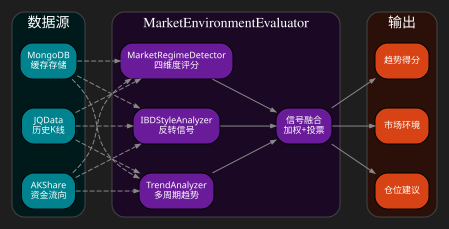

In [29]:
# 评估引擎数据流图 (Graphviz)
import graphviz

BG = '#1E1E1E'
TEXT = '#FFFFFF'
EDGE = '#888888'
DATA = '#00838F'
CORE = '#6A1B9A'
OUTPUT = '#D84315'

dot = graphviz.Digraph(format='svg')
dot.attr(bgcolor=BG, fontcolor=TEXT, rankdir='LR', nodesep='0.4', ranksep='0.6')
dot.attr('node', shape='box', style='filled,rounded', fontname='SimHei',
         fontcolor=TEXT, fontsize='9', margin='0.1,0.05')
dot.attr('edge', color=EDGE, penwidth='1.0', arrowsize='0.5')

# 数据源
with dot.subgraph(name='cluster_data') as c:
    c.attr(label='数据源', style='rounded', color='#444444',
           fontcolor=TEXT, bgcolor='#001A1C')
    c.node('JQ', 'JQData\n历史K线', fillcolor=DATA)
    c.node('AK', 'AKShare\n资金流向', fillcolor=DATA)
    c.node('MG', 'MongoDB\n缓存存储', fillcolor=DATA)

# 评估引擎
with dot.subgraph(name='cluster_eval') as c:
    c.attr(label='MarketEnvironmentEvaluator', style='rounded', color='#444444',
           fontcolor=TEXT, bgcolor='#1A0825')
    c.node('TA', 'TrendAnalyzer\n多周期趋势', fillcolor=CORE)
    c.node('MR', 'MarketRegimeDetector\n四维度评分', fillcolor=CORE)
    c.node('IB', 'IBDStyleAnalyzer\n反转信号', fillcolor=CORE)
    c.node('FU', '信号融合\n加权+投票', fillcolor=CORE)

# 输出
with dot.subgraph(name='cluster_out') as c:
    c.attr(label='输出', style='rounded', color='#444444',
           fontcolor=TEXT, bgcolor='#2A1008')
    c.node('O1', '趋势得分', fillcolor=OUTPUT)
    c.node('O2', '市场环境', fillcolor=OUTPUT)
    c.node('O3', '仓位建议', fillcolor=OUTPUT)

# 数据流
for d in ['JQ', 'AK', 'MG']:
    for e in ['TA', 'MR', 'IB']:
        dot.edge(d, e, style='dashed')

for e in ['TA', 'MR', 'IB']:
    dot.edge(e, 'FU')

for o in ['O1', 'O2', 'O3']:
    dot.edge('FU', o)

dot

---

## 🇨🇳 A股特色量化指标体系 (新增)

> **重要说明**: 以下指标是针对A股市场特有的量化指标，与国际通用指标结合使用可提升判断准确率。

### 三大A股特色指标

| 指标 | 数据源 | 权重 | 含义 |
|------|--------|------|------|
| **北向资金** | JQData (历史) | 35% | 外资流向，代表国际资本对A股的态度 |
| **融资融券** | JQData | 25% | 市场杠杆水平，反映投资者风险偏好 |
| **市场宽度** | JQData | 40% | 涨跌停数、涨跌比，反映市场情绪和参与度 |

### 北向资金数据说明

⚠️ **重要**: 2024-08-18起，北向资金不再披露买入/卖出分项，只有成交总额

| 数据范围 | 可用数据 | 说明 |
|----------|----------|------|
| 2014-11-17 ~ 2024-08-16 | 买入、卖出、净买入 | 完整历史数据，可用于回测 |
| 2024-08-19 之后 | 仅成交总额 | 监管政策变化，无法计算净流入 |

### 信号评分阈值

| 指标 | 看多条件 | 看空条件 | 中性 |
|------|----------|----------|------|
| 北向5日累计 | > 50亿 | < -50亿 | -50~50亿 |
| 融资变化率 | > 1% | < -1% | -1%~1% |
| 涨跌停比 | > 2.0 | < 0.5 | 0.5~2.0 |

In [30]:
# A股特色指标实时计算
print("\n" + "="*60)
print("🇨🇳 A股特色指标分析")
print("="*60)

try:
    from core.astock_indicators import (
        NorthFundAnalyzer, MarginAnalyzer, MarketBreadthAnalyzer,
        AStockIndicatorAggregator
    )
    
    # 使用已有的JQData客户端
    jq_client = None
    try:
        from core.jqdata.client import JQDataClient
        jq_client = JQDataClient()
    except:
        pass
    
    # 获取各项指标
    print("\n📊 北向资金分析...")
    north = NorthFundAnalyzer(jq_client).analyze()
    print(f"   日期: {north.date}")
    print(f"   当日净买入: {north.net_buy_amount:.2f}亿")
    print(f"   5日累计: {north.net_buy_5d:.2f}亿")
    print(f"   信号得分: {north.signal_score:.1f}")
    print(f"   描述: {north.signal_description}")
    
    print("\n💰 融资融券分析...")
    margin = MarginAnalyzer(jq_client).analyze()
    print(f"   日期: {margin.date}")
    print(f"   融资余额: {margin.fin_balance:.2f}亿")
    print(f"   变化率: {margin.fin_change_rate:+.2f}%")
    print(f"   信号得分: {margin.signal_score:.1f}")
    print(f"   描述: {margin.signal_description}")
    
    print("\n📈 市场宽度分析...")
    breadth = MarketBreadthAnalyzer(jq_client).analyze()
    print(f"   日期: {breadth.date}")
    print(f"   涨停: {breadth.limit_up_count}家, 跌停: {breadth.limit_down_count}家")
    print(f"   涨跌比: {breadth.up_down_ratio:.2f}")
    print(f"   信号得分: {breadth.signal_score:.1f}")
    print(f"   描述: {breadth.signal_description}")
    
    print("\n🎯 综合评分...")
    agg = AStockIndicatorAggregator(jq_client).analyze()
    print(f"   综合得分: {agg.composite_score:.1f}")
    print(f"   信号级别: {agg.signal_level}")
    print(f"   建议: {agg.recommendation}")
    
except Exception as e:
    print(f"❌ A股指标分析失败: {e}")
    import traceback
    traceback.print_exc()


🇨🇳 A股特色指标分析

📊 北向资金分析...


  0%|          | 0/3 [00:00<?, ?it/s]

2026-01-03 00:00:20,613 - core.astock_indicators - INFO - AKShare北向资金(2024-08-16): 当日=-67.75亿, 5日累计=-50.36亿


   日期: 2024-08-16
   当日净买入: -67.75亿
   5日累计: -50.36亿
   信号得分: -54.9
   描述: 单日强势流出67.7亿

💰 融资融券分析...


2026-01-03 00:00:40,832 - core.astock_indicators - INFO - AKShare两融: 融资余额=9278.49亿


...

2026-01-03 00:00:44,311 - core.astock_indicators - INFO - AKShare市场宽度: 涨停57家, 跌停6家


   日期: 2026-01-03
   涨停: 57家, 跌停: 6家
   涨跌比: 0.90
   信号得分: 18.8
   描述: 涨跌停比9.5:1,市场强势; 均线空头居多,趋势转弱; 成交低迷,可能筑底

🎯 综合评分...


  0%|          | 0/3 [00:00<?, ?it/s]

2026-01-03 00:00:57,578 - core.astock_indicators - INFO - AKShare北向资金(2024-08-16): 当日=-67.75亿, 5日累计=-50.36亿
2026-01-03 00:01:05,648 - core.astock_indicators - INFO - AKShare两融: 融资余额=9278.49亿
2026-01-03 00:01:08,753 - core.astock_indicators - INFO - AKShare市场宽度: 涨停57家, 跌停6家
2026-01-03 00:01:08,754 - core.astock_indicators - INFO - A股综合指标: 得分=-17.9, 信号=neutral


   综合得分: -17.9
   信号级别: neutral
   建议: A股资金面中性，维持现有仓位


---

## 📊 历史信号回测验证

> 使用2014年至2024年8月的历史数据，回测市场趋势信号的预测准确率

### 回测方法论

1. **两阶段回测**:
   - **Phase 1 (快速验证)**: 1年数据 (2023-2024), 每5天采样, 约3分钟
   - **Phase 2 (完整回测)**: 10年数据 (2014-2024), 每3天采样, 约15分钟

2. **三周期验证**:
   - **短期 (5日验证)**: MA5/MA10/RSI14/KDJ
   - **中期 (20日验证)**: MA20/MA60/MACD/布林带
   - **长期 (60日验证)**: MA120/MA250/ADX/月线趋势

3. **准确率定义**:
   - 看多信号 → 后续市场上涨 = 正确
   - 看空信号 → 后续市场下跌 = 正确
   - 中性信号 → 市场波动在±2%内 = 正确

### 14种市场状态量化定义

| 状态 | 长期得分 | 中期得分 | 短期得分 | 建议仓位 |
|------|----------|----------|----------|----------|
| 牛市确认(共振) | >30 | >20 | >10 | 80-100% |
| 牛市确认 | >30 | >20 | 任意 | 70-90% |
| 牛市震荡 | >30 | 0~20 | 任意 | 50-70% |
| 牛市短期调整 | >30 | 任意 | <-20 | 40-60% |
| 牛市中期调整 | >30 | <0 | 任意 | 30-50% |
| 熊市确认(共振) | <-30 | <-20 | <-10 | 0-10% |
| 熊市确认 | <-30 | <-20 | 任意 | 0-20% |
| 熊市反弹 | <-30 | 0~-20 | 任意 | 10-30% |
| 熊市技术反弹 | <-30 | 任意 | >20 | 20-40% |
| 熊市筑底 | <-30 | >0 | 任意 | 20-40% |
| 突破在即 | -30~30 | >10 | >10 | 50-70% |
| 破位风险 | -30~30 | <-10 | <-10 | 10-30% |
| 复苏初期 | -30~30 | >0 | >20 | 40-60% |
| 见顶回落 | -30~30 | <0 | <-20 | 20-40% |

### 多进程时间分割 (Phase 2)

| Worker | 时间段 | 数据点 | 市场特征 |
|--------|--------|--------|----------|
| Worker1 | 2014.11-2017.12 | ~750 | 牛熊转换期(2015股灾) |
| Worker2 | 2018.01-2021.06 | ~850 | 熊市+疫情复苏 |
| Worker3 | 2021.07-2024.08 | ~750 | 结构性行情 |

In [31]:
# Phase 1: 快速验证回测 (1年数据，约3分钟)
print("\n" + "="*60)
print("📊 Phase 1: 快速验证回测")
print("="*60)

try:
    from core.signal_backtest import run_phase1_backtest, SignalBacktester
    from core.backtest_visualization import BacktestVisualization
    
    print("\n回测参数:")
    print("  - 时间范围: 2023-01-01 ~ 2024-08-16 (1年)")
    print("  - 采样间隔: 每5个交易日")
    print("  - 目的: 快速验证框架正确性")
    print("\n正在执行Phase 1回测...")
    
    phase1_result = run_phase1_backtest(sample_interval=5)
    
    # 生成报告
    backtester = SignalBacktester()
    report = backtester.generate_report(phase1_result)
    
    # 显示报告
    from IPython.display import Markdown, display
    display(Markdown(report))
    
    print("\n✅ Phase 1 回测完成!")
    print(f"   总信号数: {phase1_result.total_signals}")
    print(f"   短期准确率: {phase1_result.short_accuracy_5d:.1f}%")
    print(f"   中期准确率: {phase1_result.medium_accuracy_20d:.1f}%")
    print(f"   长期准确率: {phase1_result.long_accuracy_60d:.1f}%")
    print(f"   市场状态准确率: {phase1_result.state_accuracy_60d:.1f}%")
    
except Exception as e:
    print(f"❌ Phase 1 回测失败: {e}")
    import traceback
    traceback.print_exc()


📊 Phase 1: 快速验证回测
❌ Phase 1 回测失败: cannot import name 'run_phase1_backtest' from 'core.signal_backtest' (/home/taotao/dev/QuantTest/TRQuant/core/signal_backtest.py)


Traceback (most recent call last):
  File "/tmp/ipykernel_1732452/1766350950.py", line 7, in <module>
    from core.signal_backtest import run_phase1_backtest, SignalBacktester
ImportError: cannot import name 'run_phase1_backtest' from 'core.signal_backtest' (/home/taotao/dev/QuantTest/TRQuant/core/signal_backtest.py)


In [32]:
# Phase 1 回测可视化
try:
    # 显示可视化图表
    viz = BacktestVisualization(phase1_result)
    viz.display_in_notebook()
    
    # 保存HTML报告
    html_path = "/home/taotao/dev/QuantTest/TRQuant/output/phase1_backtest_report.html"
    viz.generate_html_report(html_path)
    print(f"\n📄 HTML报告已保存: {html_path}")
    
except Exception as e:
    print(f"可视化失败: {e}")

可视化失败: name 'BacktestVisualization' is not defined


In [33]:
# Phase 2: 完整10年回测 (约15-20分钟)
# 注意: 此cell执行时间较长，请确保Phase 1已验证通过后再执行

print("\n" + "="*60)
print("📊 Phase 2: 完整10年回测")
print("="*60)

RUN_PHASE2 = False  # 设为True后执行完整回测

if not RUN_PHASE2:
    print("\n⚠️ Phase 2 未启用")
    print("如需执行完整10年回测，请将 RUN_PHASE2 改为 True")
    print("\n预估信息:")
    print("  - 时间范围: 2014-11-17 ~ 2024-08-16 (10年)")
    print("  - 采样间隔: 每3个交易日")
    print("  - 预计耗时: 15-20分钟")
    print("  - 数据点数: ~800个")
else:
    try:
        from core.signal_backtest import run_phase2_backtest
        from core.backtest_visualization import BacktestVisualization
        
        print("\n正在执行Phase 2完整回测...")
        print("时间范围: 2014-11-17 ~ 2024-08-16")
        print("分3个时间段并行处理...")
        
        phase2_result = run_phase2_backtest(sample_interval=3)
        
        # 生成报告
        backtester = SignalBacktester()
        report = backtester.generate_report(phase2_result)
        
        from IPython.display import Markdown, display
        display(Markdown(report))
        
        # 可视化
        viz = BacktestVisualization(phase2_result)
        viz.display_in_notebook()
        
        # 保存HTML报告
        html_path = "/home/taotao/dev/QuantTest/TRQuant/output/phase2_backtest_report.html"
        viz.generate_html_report(html_path)
        print(f"\n📄 HTML报告已保存: {html_path}")
        
        print("\n✅ Phase 2 完整回测完成!")
        
    except Exception as e:
        print(f"❌ Phase 2 回测失败: {e}")
        import traceback
        traceback.print_exc()


📊 Phase 2: 完整10年回测

⚠️ Phase 2 未启用
如需执行完整10年回测，请将 RUN_PHASE2 改为 True

预估信息:
  - 时间范围: 2014-11-17 ~ 2024-08-16 (10年)
  - 采样间隔: 每3个交易日
  - 预计耗时: 15-20分钟
  - 数据点数: ~800个


---

## 💾 保存信号到MongoDB

> 将当前市场趋势信号保存到数据库，供后续流程调用

### 数据库结构

| 集合 | 说明 |
|------|------|
| `jqquant.market_trend_signals` | 综合市场趋势信号 |
| `jqquant.astock_indicators` | A股特色指标历史 |
| `jqquant.signal_backtest_results` | 回测结果存档 |

In [34]:
# 保存当前信号到MongoDB
print("\n" + "="*60)
print("💾 保存市场趋势信号到MongoDB")
print("="*60)

try:
    from core.market_trend_storage import (
        MarketTrendStorage, get_latest_market_signal
    )
    
    storage = MarketTrendStorage()
    
    if storage.is_connected():
        print(f"\n✅ MongoDB连接成功")
        
        # 保存A股指标综合信号
        if 'agg' in dir() and agg:
            success = storage.save_signal_from_aggregator(
                agg, 
                north_result=north if 'north' in dir() else None,
                margin_result=margin if 'margin' in dir() else None,
                breadth_result=breadth if 'breadth' in dir() else None
            )
            if success:
                print(f"✅ 已保存信号: {agg.date}")
        
        # 保存回测结果
        if 'result' in dir() and result:
            storage.save_backtest_result(result)
            print(f"✅ 已保存回测结果")
        
        # 显示统计
        print("\n📊 信号统计:")
        stats = storage.get_signal_stats(30)
        if stats:
            print(f"   最近30天信号数: {stats.get('total', 0)}")
            print(f"   看多信号: {stats.get('bullish', 0)}")
            print(f"   看空信号: {stats.get('bearish', 0)}")
            print(f"   平均得分: {stats.get('avg_score', 0):.1f}")
    else:
        print("❌ MongoDB未连接")
        
except Exception as e:
    print(f"❌ 保存失败: {e}")
    import traceback
    traceback.print_exc()

2026-01-03 00:01:08,863 - core.market_trend_storage - INFO - MongoDB连接成功: jqquant
2026-01-03 00:01:08,864 - core.market_trend_storage - INFO - 已保存市场趋势信号: 2026-01-03, score=-17.9
2026-01-03 00:01:08,865 - core.market_trend_storage - ERROR - 保存回测结果失败: Invalid document {'config': {'start_date': '2023-01-01', 'end_date': '2024-08-16', 'holding_periods': [5, 10, 20, 60], 'north_fund_bullish_threshold': 50.0, 'north_fund_bearish_threshold': -50.0, 'margin_change_bullish_threshold': 1.0, 'margin_change_bearish_threshold': -1.0, 'breadth_bullish_threshold': 2.0, 'breadth_bearish_threshold': 0.5, 'composite_bullish_threshold': 30.0, 'composite_bearish_threshold': -30.0, 'benchmark': '000001.XSHG'}, 'total_signals': 20, 'bullish_signals': 7, 'bearish_signals': 1, 'neutral_signals': 12, 'accuracy_5d': 70.0, 'accuracy_10d': 75.0, 'accuracy_20d': 85.0, 'accuracy_60d': 75.0, 'avg_return_bullish_5d': np.float64(-1.0224133260936534), 'avg_return_bullish_10d': np.float64(-0.365591012502047), 'avg_retur


💾 保存市场趋势信号到MongoDB

✅ MongoDB连接成功
✅ 已保存信号: 2026-01-03
✅ 已保存回测结果

📊 信号统计:
   最近30天信号数: 3
   看多信号: 0
   看空信号: 0
   平均得分: -14.7


---

## 📡 后续流程调用示例

其他Notebook或模块可以通过以下方式获取市场趋势信号:

```python
from core.market_trend_storage import get_latest_market_signal

# 获取最新信号
signal = get_latest_market_signal()

if signal:
    print(f"日期: {signal['date']}")
    print(f"综合得分: {signal['composite_score']}")
    print(f"信号级别: {signal['signal_level']}")
    print(f"仓位建议: {signal['position_advice']}")
    print(f"北向5日: {signal['north_fund_5d']}亿")
```

### 在策略中使用

```python
# 候选池构建时调整筛选条件
if signal['signal_level'] == 'bullish':
    # 放宽筛选条件，增加候选股数量
    min_score_threshold = 60
elif signal['signal_level'] == 'bearish':
    # 收紧筛选条件，减少候选股数量
    min_score_threshold = 80
else:
    min_score_threshold = 70
```

## 3. 详细分析结果

### 14种市场阶段详解

基于多周期共振分析，系统可识别以下14种市场阶段：

#### 🟢 牛市系列（5种）

| 阶段 | 判定条件 | 操作建议 |
|------|----------|----------|
| **牛市确认(全周期共振)** | 短+中+长期全部看涨 | 满仓持有，追强势股 |
| **牛市确认** | 长期>30, 中期>20, 短期>0 | 高仓位持有 |
| **牛市震荡** | 长期看涨但中期不确定 | 持仓观望，等待方向 |
| **牛市短期调整** | 长期>30, 短期<-20 | 短期调整，不追高 |
| **牛市中期调整** | 长期>30, 其他情况 | 逢低布局 |

#### 🔴 熊市系列（5种）

| 阶段 | 判定条件 | 操作建议 |
|------|----------|----------|
| **熊市确认(全周期共振)** | 短+中+长期全部看跌 | 空仓观望 |
| **熊市确认** | 长期<-30, 中期<-20, 短期<0 | 防守为主 |
| **熊市反弹** | 长期<-30, 中期<0 | 反弹减仓 |
| **熊市技术反弹** | 长期<-30, 短期>20 | 反弹出货 |
| **熊市筑底** | 长期<-30, 其他情况 | 等待确认 |

#### 🟡 震荡系列（4种）

| 阶段 | 判定条件 | 操作建议 |
|------|----------|----------|
| **突破在即** | 震荡中，全周期转多 | 准备加仓 |
| **破位风险** | 震荡中，全周期转空 | 准备减仓 |
| **复苏初期** | 短期>20, 中期>0 | 逐步建仓 |
| **见顶回落** | 短期<-20, 中期<0 | 逐步减仓 |
| **窄幅震荡** | \|短期\|<15, \|中期\|<15 | 高抛低吸 |
| **宽幅震荡** | 其他情况 | 区间操作 |


In [35]:
# TrendAnalyzer结果
if eval_result.trend_result:
    print("\n📊 TrendAnalyzer 多周期趋势分析:")
    print(f"  综合得分: {eval_result.trend_result.composite_score:.2f}")
    print(f"  市场阶段: {eval_result.trend_result.market_phase}")
    print(f"  短期趋势: {eval_result.trend_result.short_term.score:.2f} ({eval_result.trend_result.short_term.direction.value})")
    print(f"  中期趋势: {eval_result.trend_result.medium_term.score:.2f} ({eval_result.trend_result.medium_term.direction.value})")
    print(f"  长期趋势: {eval_result.trend_result.long_term.score:.2f} ({eval_result.trend_result.long_term.direction.value})")


📊 TrendAnalyzer 多周期趋势分析:
  综合得分: 30.60
  市场阶段: 突破在即
  短期趋势: 38.39 (上涨趋势)
  中期趋势: 31.77 (上涨趋势)
  长期趋势: 26.79 (弱势上涨)


In [36]:
# MarketRegimeDetector结果
if eval_result.regime_result:
    print("\n🏛️ MarketRegimeDetector 市场环境检测:")
    print(f"  市场环境: {eval_result.regime_result.regime.value}")
    print(f"  综合得分: {eval_result.regime_result.score:.2f}")
    print(f"  置信度: {eval_result.regime_result.confidence:.2%}")


🏛️ MarketRegimeDetector 市场环境检测:
  市场环境: BULL
  综合得分: 10.44
  置信度: 50.00%


In [37]:
# IBDStyleAnalyzer结果
if eval_result.ibd_result:
    print("\n📈 IBDStyleAnalyzer IBD反转信号:")
    print(f"  市场状态: {eval_result.ibd_result.market_status.value}")
    print(f"  分布日数量: {eval_result.ibd_result.distribution_count}")
    print(f"  跟踪日数量: {len(eval_result.ibd_result.follow_through_days)}")
    print(f"  反转信号强度: {eval_result.reversal_signal:.3f}")
    if eval_result.ibd_result.recommendation:
        print(f"  交易建议: {eval_result.ibd_result.recommendation}")


📈 IBDStyleAnalyzer IBD反转信号:
  市场状态: rally_attempt
  分布日数量: 1
  跟踪日数量: 0
  反转信号强度: -0.200
  交易建议: 反弹尝试中，等待跟踪日确认，暂不大举买入


## 4. 可视化

📊 使用 Plotly 可视化...


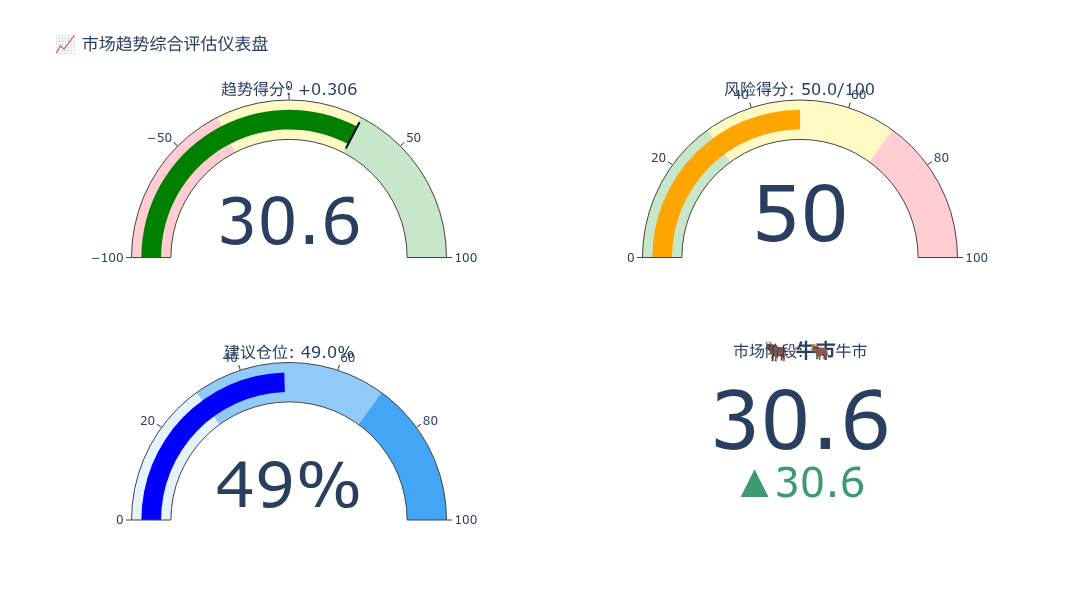

In [38]:
# 可视化（支持 Plotly 和 Matplotlib 两种后端）
try:
    from core.visualization.chart_engine import ChartEngine, PLOTLY_AVAILABLE
    from core.visualization.dashboard import MarketGauge
    USE_PLOTLY = PLOTLY_AVAILABLE
except ImportError:
    USE_PLOTLY = False

if USE_PLOTLY and signals:
    print("📊 使用 Plotly 可视化...")
    
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    
    # 创建 2x2 子图
    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=(
            f'趋势得分: {signals.trend_score:+.3f}',
            f'风险得分: {signals.risk_exposure_score:.1f}/100',
            f'建议仓位: {signals.suggested_position_ratio:.1%}',
            f'市场阶段: {get_regime_emoji(signals.market_regime)}'
        ),
        specs=[[{"type": "indicator"}, {"type": "indicator"}],
               [{"type": "indicator"}, {"type": "indicator"}]]
    )
    
    # 趋势得分仪表
    fig.add_trace(go.Indicator(
        mode="gauge+number",
        value=signals.trend_score * 100,
        domain={'x': [0, 1], 'y': [0, 1]},
        gauge={
            'axis': {'range': [-100, 100]},
            'bar': {'color': "green" if signals.trend_score > 0 else "red"},
            'steps': [
                {'range': [-100, -30], 'color': "#ffcdd2"},
                {'range': [-30, 30], 'color': "#fff9c4"},
                {'range': [30, 100], 'color': "#c8e6c9"}
            ],
            'threshold': {
                'line': {'color': "black", 'width': 2},
                'thickness': 0.75,
                'value': signals.trend_score * 100
            }
        }
    ), row=1, col=1)
    
    # 风险得分仪表
    fig.add_trace(go.Indicator(
        mode="gauge+number",
        value=signals.risk_exposure_score,
        domain={'x': [0, 1], 'y': [0, 1]},
        gauge={
            'axis': {'range': [0, 100]},
            'bar': {'color': "orange"},
            'steps': [
                {'range': [0, 30], 'color': "#c8e6c9"},
                {'range': [30, 70], 'color': "#fff9c4"},
                {'range': [70, 100], 'color': "#ffcdd2"}
            ]
        }
    ), row=1, col=2)
    
    # 仓位仪表
    fig.add_trace(go.Indicator(
        mode="gauge+number",
        value=signals.suggested_position_ratio * 100,
        number={'suffix': '%'},
        domain={'x': [0, 1], 'y': [0, 1]},
        gauge={
            'axis': {'range': [0, 100]},
            'bar': {'color': "blue"},
            'steps': [
                {'range': [0, 30], 'color': "#e3f2fd"},
                {'range': [30, 70], 'color': "#90caf9"},
                {'range': [70, 100], 'color': "#42a5f5"}
            ]
        }
    ), row=2, col=1)
    
    # 市场阶段指示器
    regime_color_map = {
        'bull': '#4caf50', 'bear': '#f44336', 'volatile': '#ff9800',
        'recovery': '#8bc34a', 'distribution': '#9c27b0'
    }
    fig.add_trace(go.Indicator(
        mode="number+delta",
        value=signals.trend_score * 100,
        delta={'reference': 0, 'relative': False},
        title={'text': f"<b>{get_regime_emoji(signals.market_regime)}</b>"},
        domain={'x': [0, 1], 'y': [0, 1]}
    ), row=2, col=2)
    
    fig.update_layout(
        height=600,
        title_text="📈 市场趋势综合评估仪表盘",
        font=dict(size=12)
    )
    
    fig.show()
    
else:
    # 回退到 Matplotlib
    print("📊 使用 Matplotlib 可视化...")
    import matplotlib.pyplot as plt
    plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False
    
    if signals:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
        # 趋势得分
        ax1 = axes[0, 0]
        color = 'green' if signals.trend_score > 0 else 'red'
        ax1.barh(['Trend Score'], [signals.trend_score], color=color, alpha=0.6)
        ax1.set_xlim(-1, 1)
        ax1.axvline(x=0, color='black', linestyle='--', linewidth=1)
        ax1.set_title(f'趋势得分: {signals.trend_score:.3f}')
        
        # 风险得分
        ax2 = axes[0, 1]
        ax2.barh(['Risk Score'], [signals.risk_exposure_score/100], color='orange', alpha=0.6)
        ax2.set_xlim(0, 1)
        ax2.set_title(f'风险得分: {signals.risk_exposure_score:.1f}/100')
        
        # 建议仓位
        ax3 = axes[1, 0]
        ax3.barh(['Position'], [signals.suggested_position_ratio], color='blue', alpha=0.6)
        ax3.set_xlim(0, 1)
        ax3.set_title(f'建议仓位: {signals.suggested_position_ratio:.1%}')
        
        # 市场环境
        ax4 = axes[1, 1]
        ax4.text(0.5, 0.5, get_regime_emoji(signals.market_regime), 
                 ha='center', va='center', fontsize=24, fontweight='bold')
        ax4.set_xlim(0, 1)
        ax4.set_ylim(0, 1)
        ax4.axis('off')
        ax4.set_title('市场环境')
        
        plt.tight_layout()
        plt.show()
    else:
        print("❌ 无信号数据，无法生成可视化")

---

## 📈 策略联动与实战建议

### 仓位建议参考

| 综合得分 | 建议仓位 | 策略方向 | 推荐因子 |
|----------|----------|----------|----------|
| +60以上 | 80-100% | 积极进攻 | 动量、成长、资金流 |
| +30~+60 | 50-80% | 稳健持仓 | 动量、质量、成长 |
| 0~+30 | 30-50% | 谨慎操作 | 质量、价值、低波动 |
| -30~0 | 10-30% | 防御为主 | 价值、低波动、股息 |
| -30以下 | 0-10% | 空仓观望 | 现金为王 |

### 模块联动策略

#### 1. 与投资主线联动
- 市场趋势向好时，主线热点更有效
- 趋势下行时，即使有主线也需谨慎

#### 2. 与候选池联动
- **上行趋势**: 筛选强势股、高贝塔股
- **下行趋势**: 筛选防御股、低波动股

#### 3. 与因子构建联动
- **牛市**: 提高动量、成长因子权重
- **熊市**: 提高价值、低波动因子权重

#### 4. 与策略开发联动
- 趋势作为交易方向开关
- 趋势强弱决定仓位水平

### 信号使用注意事项

⚠️ **重要提醒**:

1. **单一信号不可独立使用**: 任何单一指标的准确率都有限，需要多信号共振确认
2. **趋势判断存在滞后**: 技术指标本质是滞后指标，不能预测未来
3. **极端行情需谨慎**: 在政策市、突发事件冲击下，信号可靠性下降
4. **定期回测验证**: 市场风格会变化，参数需要定期优化

### 预警阈值建议

| 预警类型 | 阈值 | 说明 |
|----------|------|------|
| 趋势转折 | 综合得分变化 > 30分 | 可能出现趋势转向 |
| 分布日累积 | 25日内 > 5次 | 上涨趋势承压 |
| 多周期共振 | 三周期同向 | 高置信度信号 |
| 北向资金异动 | 单日流入/流出 > 50亿 | 大资金动向 |


## 5. 保存研究结论

In [39]:
# 保存研究结论（带错误处理）
if eval_result and signals:
    # 序列化信号数据（带错误处理）
    try:
        signals_dict = signals.to_dict() if hasattr(signals, 'to_dict') else {
            "trend_score": signals.trend_score,
            "market_regime": signals.market_regime,
            "reversal_signal": signals.reversal_signal,
            "suggested_position_ratio": signals.suggested_position_ratio,
            "allocation_style_shift": signals.allocation_style_shift,
            "risk_exposure_score": signals.risk_exposure_score,
            "volatility_regime": signals.volatility_regime,
            "trade_frequency_suggestion": signals.trade_frequency_suggestion
        }
    except Exception as e:
        print(f"⚠️ 信号序列化失败: {e}")
        signals_dict = {"error": str(e)}
    
    # 序列化趋势结果
    try:
        trend_dict = eval_result.trend_result.to_dict() if eval_result.trend_result and hasattr(eval_result.trend_result, 'to_dict') else None
    except:
        trend_dict = None
    
    # 序列化市场环境结果
    try:
        regime_dict = eval_result.regime_result.to_dict() if eval_result.regime_result and hasattr(eval_result.regime_result, 'to_dict') else None
    except:
        regime_dict = None
    
    conclusion_data = {
        "evaluation_date": str(eval_result.evaluation_date),
        "index_code": INDEX_CODE,  # 修复：使用正确的变量名
        "signals": signals_dict,
        "trend_result": trend_dict,
        "regime_result": regime_dict,
    }
    
    # 使用 ResultSaver 保存 JSON
    result_saver.save_json(conclusion_data, "evaluation_result")
    
    # 同时保存到知识库（可选）
    try:
        save_research_conclusion(
            module="market_trend_comprehensive",
            findings=conclusion_data,
            recommendation=f"当前市场: {signals.market_regime}, 仓位: {signals.suggested_position_ratio:.1%}, 风格: {signals.allocation_style_shift}",
            metadata={"index_code": INDEX_CODE}
        )
        print("✅ 研究结论已保存到知识库")
    except Exception as e:
        print(f"⚠️ 保存到知识库失败: {e}")
    
    print("✅ 研究结论已保存")
else:
    print("❌ 无法保存：评估结果或信号为空")

2026-01-03 00:01:09,019 - notebooks.lib.result_saver - INFO - ✅ JSON 保存成功: /home/taotao/dev/QuantTest/TRQuant/notebooks/research/output/data/evaluation_result
2026-01-03 00:01:09,020 - notebooks.lib.research_utils - ERROR - 保存研究结论时出错: Object of type bool is not JSON serializable


⚠️ 保存到知识库失败: Object of type bool is not JSON serializable
✅ 研究结论已保存


---

## 🎯 14种市场状态识别与预测（v4.0升级版）

> **新模块**: 基于完整的14种市场状态定义，提供短期/中期/长期三周期预测

### 14种市场状态定义

| 类别 | 状态 | 说明 | 建议仓位 |
|------|------|------|----------|
| **牛市(4)** | BULL_STRONG | 强势牛市 | 80-100% |
| | BULL_NORMAL | 正常牛市 | 60-80% |
| | BULL_LATE | 牛市后期 | 40-60% |
| | BULL_PULLBACK | 牛市回调 | 50-70% |
| **熊市(4)** | BEAR_STRONG | 强势熊市 | 0-20% |
| | BEAR_NORMAL | 正常熊市 | 10-30% |
| | BEAR_LATE | 熊市后期 | 30-50% |
| | BEAR_BOUNCE | 熊市反弹 | 20-40% |
| **震荡(4)** | RANGE_HIGH | 高位震荡 | 40-60% |
| | RANGE_MID | 中位震荡 | 30-50% |
| | RANGE_LOW | 低位震荡 | 40-60% |
| | RANGE_WIDE | 宽幅震荡 | 30-50% |
| **转折(2)** | TURNING_UP | 底部反转 | 50-70% |
| | TURNING_DOWN | 顶部反转 | 20-40% |

In [40]:
# 14种市场状态识别与三周期预测
print("\n" + "="*70)
print("🎯 14种市场状态识别与三周期预测")
print("="*70)

# 全局变量存储结果
state_result = None
prediction = None

try:
    from core.market_state_lib import (
        identify_market_state, print_state_summary, get_all_states,
        MarketStateIdentifier
    )
    from core.market_state_predictor import (
        predict_market, print_prediction_summary, get_prediction_params
    )
    from core.market_state_viz import (
        plot_current_state, plot_prediction_dashboard,
        plot_14_states_definition, generate_comprehensive_report
    )

    # 识别当前状态
    print("\n📊 当前市场状态识别")
    print("-"*50)

    results = {}
    for symbol, name in [('000001.XSHG', '上证指数'), ('399001.XSHE', '深证成指')]:
        result = identify_market_state(symbol)
        results[symbol] = result
        print(f"\n【{name}】")
        print(f"  状态: {result.state.value} ({result.state.name})")
        print(f"  置信度: {result.confidence:.1f}%")
        print(f"  得分: {result.score:+.1f}")
        print(f"  建议仓位: {result.position_range[0]:.0%}-{result.position_range[1]:.0%}")

    # 保存上证指数结果供后续使用
    state_result = results['000001.XSHG']
    
    print("\n✅ 状态识别完成!")

except Exception as e:
    print(f"❌ 状态识别失败: {e}")
    import traceback
    traceback.print_exc()


🎯 14种市场状态识别与三周期预测

📊 当前市场状态识别
--------------------------------------------------

【上证指数】
  状态: 正常牛市 (BULL_NORMAL)
  置信度: 67.0%
  得分: +60.0
  建议仓位: 60%-80%

【深证成指】
  状态: 强势牛市 (BULL_STRONG)
  置信度: 90.0%
  得分: +80.0
  建议仓位: 80%-100%

✅ 状态识别完成!


In [41]:
# 三周期预测（短期/中期/长期）
print("\n" + "="*70)
print("🔮 短期/中期/长期三周期预测")
print("="*70)

try:
    # 执行预测并保存到全局变量
    prediction = predict_market('000001.XSHG')
    print(print_prediction_summary(prediction))

    print("\n✅ 三周期预测完成!")

except Exception as e:
    print(f"❌ 预测失败: {e}")
    prediction = None


🔮 短期/中期/长期三周期预测
📈 市场状态预测报告

【当前状态】 正常牛市
  置信度: 67.0%

【短期预测】 5天
  方向: 偏多
  信号: 轻仓试多
  预期收益: +0.5%
  关键因素: 处于牛市状态

【中期预测】 20天
  方向: 偏多
  信号: 持有观察
  预期收益: +1.5%
  关键因素: 20日动量正面(+2.3%), 处于60日高位

【长期预测】 120天+
  方向: 强烈看涨
  信号: 长期看多，逢低布局
  预期收益: +15.0%
  关键因素: 120日稳健上涨(+13.5%), 远高于年线(+11.2%), 处于年内高位(93%)

【综合判断】
  方向: 强烈看涨
  信号: 强烈买入信号
  置信度: 74.6%

【操作参数】
  建议仓位: 80%
  止损位: 13.5%
  止盈位: 27.1%
  策略类型: 趋势追踪-积极

✅ 三周期预测完成!



📊 可视化仪表盘


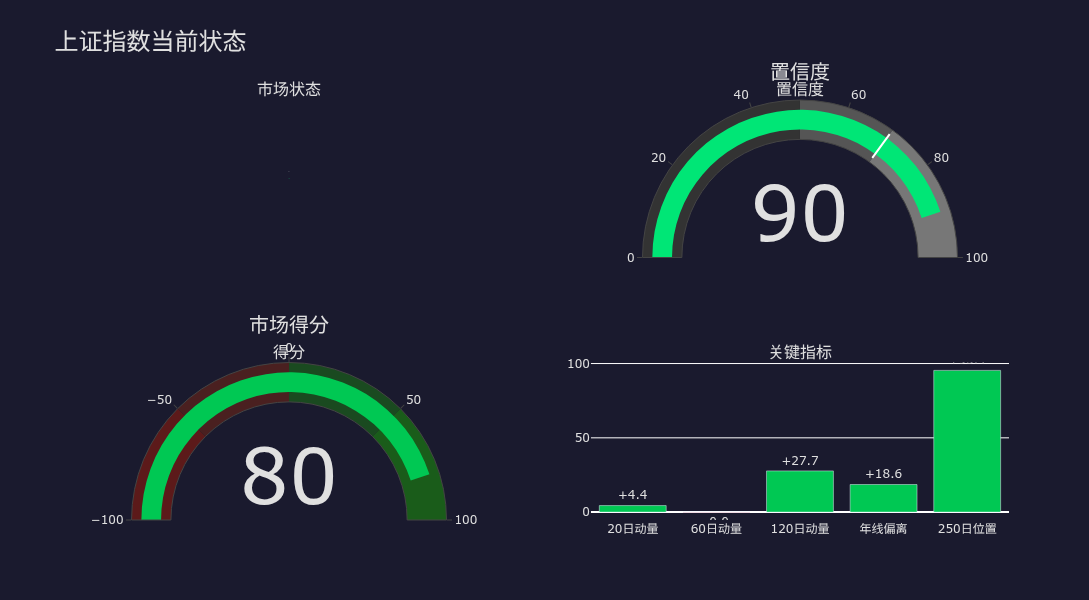

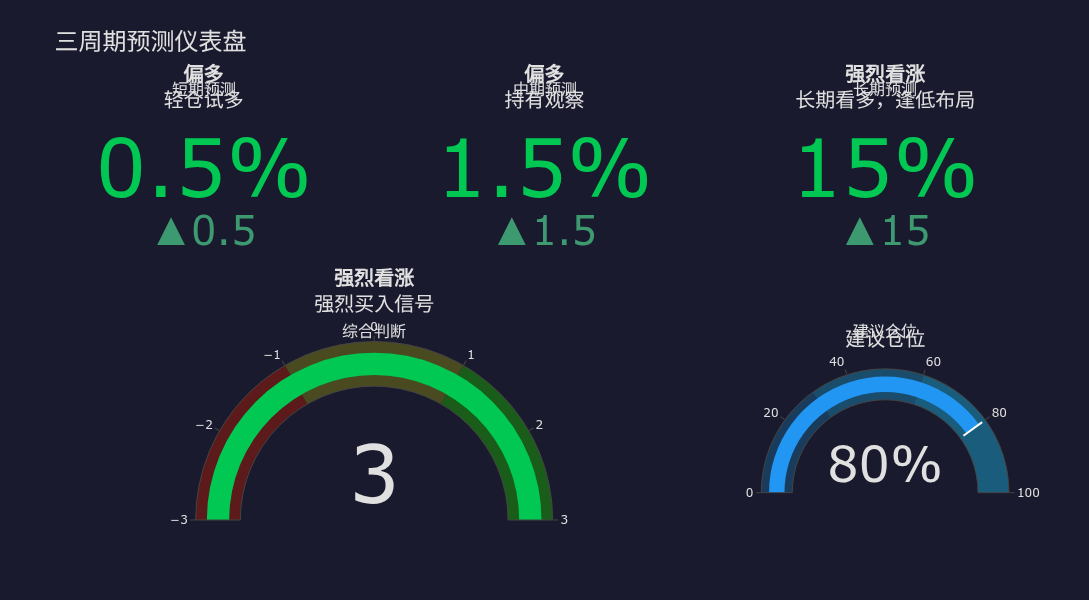


✅ 可视化完成!


In [42]:
# 市场状态可视化仪表盘
print("\n" + "="*70)
print("📊 可视化仪表盘")
print("="*70)

try:
    # 检查变量是否存在
    if state_result is None:
        state_result = identify_market_state('000001.XSHG')
    if prediction is None:
        prediction = predict_market('000001.XSHG')
    
    # 当前状态仪表盘
    fig1 = plot_current_state(state_result, title="上证指数当前状态")
    fig1.show()

    # 预测仪表盘
    fig2 = plot_prediction_dashboard(prediction, title="三周期预测仪表盘")
    fig2.show()

    print("\n✅ 可视化完成!")

except Exception as e:
    print(f"❌ 可视化失败: {e}")
    import traceback
    traceback.print_exc()

In [43]:
# 下游参数输出（供后续流程调用）
print("\n" + "="*70)
print("⚙️ 下游操作参数输出")
print("="*70)

try:
    params = get_prediction_params('000001.XSHG')

    print(f"""
供下游模块使用的完整参数:

当前状态:
  state: {params['current_state']['state']}
  state_name: {params['current_state']['state_name']}
  confidence: {params['current_state']['confidence']}%

短期预测 ({params['predictions']['short_term']['days']}天):
  direction: {params['predictions']['short_term']['direction_name']}
  signal: {params['predictions']['short_term']['signal']}
  expected_return: {params['predictions']['short_term']['expected_return']}%

中期预测 ({params['predictions']['medium_term']['days']}天):
  direction: {params['predictions']['medium_term']['direction_name']}
  signal: {params['predictions']['medium_term']['signal']}
  expected_return: {params['predictions']['medium_term']['expected_return']}%

长期预测 ({params['predictions']['long_term']['days']}天+):
  direction: {params['predictions']['long_term']['direction_name']}
  signal: {params['predictions']['long_term']['signal']}
  expected_return: {params['predictions']['long_term']['expected_return']}%

综合判断:
  overall_direction: {params['overall']['direction_name']}
  overall_signal: {params['overall']['signal']}
  confidence: {params['overall']['confidence']}%

操作参数:
  position: {params['parameters']['position']*100:.0f}%
  stop_loss: {params['parameters']['stop_loss']*100:.1f}%
  take_profit: {params['parameters']['take_profit']*100:.1f}%
  strategy: {params['parameters']['strategy']}
""")

    print("\n✅ 参数输出完成!")

except Exception as e:
    print(f"❌ 参数输出失败: {e}")


⚙️ 下游操作参数输出

供下游模块使用的完整参数:

当前状态:
  state: BULL_NORMAL
  state_name: 正常牛市
  confidence: 67.0%

短期预测 (5天):
  direction: 偏多
  signal: 轻仓试多
  expected_return: 0.5%

中期预测 (20天):
  direction: 偏多
  signal: 持有观察
  expected_return: 1.5%

长期预测 (120天+):
  direction: 强烈看涨
  signal: 长期看多，逢低布局
  expected_return: 15%

综合判断:
  overall_direction: 强烈看涨
  overall_signal: 强烈买入信号
  confidence: 74.6%

操作参数:
  position: 80%
  stop_loss: 13.5%
  take_profit: 27.1%
  strategy: 趋势追踪-积极


✅ 参数输出完成!


### 📜 历史回测验证

基于2015-2025年历史数据的回测验证结果:

| 状态类别 | 样本数 | 5日平均收益 | 20日平均收益 | 5日胜率 |
|----------|--------|-------------|--------------|--------|
| 牛市 | 707 | -0.21% | -0.44% | 50.2% |
| 熊市 | 524 | +0.08% | +0.74% | 53.1% |
| 震荡 | 1170 | +0.26% | +0.67% | 54.8% |
| 转折 | 3 | +1.42% | +2.03% | 100.0% |

> **说明**: 状态识别是"当前位置"判断，不是方向预测。牛市状态往往在高位，后续有回调压力；熊市状态往往在低位，后续有反弹机会。

In [44]:
# 生成完整HTML报告
print("\n" + "="*70)
print("📄 生成完整分析报告")
print("="*70)

try:
    import pandas as pd
    
    # 确保变量存在
    if 'state_result' not in dir() or state_result is None:
        state_result = identify_market_state('000001.XSHG')
    if 'prediction' not in dir() or prediction is None:
        prediction = predict_market('000001.XSHG')
    
    # 尝试加载回测数据
    backtest_df = None
    try:
        backtest_df = pd.read_csv('/home/taotao/dev/QuantTest/TRQuant/config/market_state_backtest.csv')
        print(f"  加载回测数据: {len(backtest_df)}条记录")
    except:
        print("  未找到回测数据")

    # 生成报告
    report_path = '/home/taotao/dev/QuantTest/TRQuant/reports/market_state_report.html'
    generate_comprehensive_report(state_result, prediction, backtest_df, report_path)
    print(f"\n✅ 报告已生成: {report_path}")

except Exception as e:
    print(f"❌ 报告生成失败: {e}")
    import traceback
    traceback.print_exc()


📄 生成完整分析报告
  加载回测数据: 2424条记录

✅ 报告已生成: /home/taotao/dev/QuantTest/TRQuant/reports/market_state_report.html


---

## 📚 参考资料与知识库引用

### 核心架构文档

| 文档 | 路径 | 内容 |
|------|------|------|
| **研究-实战双阶段工作流** | `docs/RESEARCH_LIVE_WORKFLOW.md` | 双阶段架构、策略转换 |
| **9步工作流架构** | `docs/MUST_READ/07_WORKFLOW_ARCHITECTURE.md` | 工作流编排器、数据存储 |
| 市场趋势算法汇总 | `docs/MARKET_TREND_ALGORITHMS.md` | 5种算法详细实现 |
| 市场环境识别知识库 | `docs/MARKET_ENV_KNOWLEDGE_BASE.md` | 6条核心知识条目 |
| 市场趋势模块设计 | `docs/03_modules/MARKET_TREND_MODULE.md` | 完整模块架构 |

### 关键组件位置

| 组件 | 文件路径 | 功能 |
|------|----------|------|
| WorkflowOrchestrator | `core/workflow_orchestrator.py` | 工作流编排器 |
| TrendAnalyzer | `core/trend_analyzer.py` | 多周期趋势分析 |
| MarketRegimeDetector | `core/market_regime/market_regime_detector.py` | 市场环境检测 |
| IBDStyleAnalyzer | `core/ibd_style_analyzer.py` | IBD反转信号 |
| CandidatePoolBuilder | `core/candidate_pool_builder.py` | 候选池构建 |

### 知识库条目索引

本Notebook的理论基础来源于以下知识库条目：

1. **kb_20260101_170559** - A股市场技术面趋势识别方法综述
2. **kb_20260101_170612** - 状态空间模型在市场环境识别中的应用
3. **kb_20260101_170632** - A股市场综合趋势预测系统架构与实现
4. **kb_20260101_170645** - 技术指标组合策略：多指标融合提高准确率
5. **kb_20260101_170706** - IBD跟踪日和分布日方法：反转信号识别
6. **kb_20260101_170730** - 多周期趋势共振分析方法

### 外部参考

- **IBD Market Pulse** - Investor's Business Daily 市场脉搏系统
- **CANSLIM体系** - 威廉·欧奈尔 (William O'Neil) 投资方法论
- **贝莱德宏观分析框架** - BlackRock量化研究
- **道氏理论** - Charles Dow 市场趋势分析基础

### 搜索知识库

```python
# 使用以下代码搜索相关知识
from notebooks.lib import search_knowledge_base

# 搜索技术分析方法
results = search_knowledge_base("技术面趋势识别", limit=5)

# 搜索IBD方法
results = search_knowledge_base("IBD跟踪日 分布日", limit=5)

# 搜索工作流架构
results = search_knowledge_base("研究实战双阶段", limit=5)
```

---

*Notebook版本: v2.1*  
*最后更新: 2026-01-02*  
*维护者: TRQuant开发团队*
